In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"djisoline","key":"dbe9fcd0dbb7fa54e164b09697943d45"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:04<00:00, 13.8MB/s]



In [ ]:
!unzip -q fer2013.zip

In [ ]:
!ls
!ls fer2013

fer2013.zip  kaggle.json  sample_data  test  train
ls: cannot access 'fer2013': No such file or directory


In [ ]:
!ls /content/train
!ls /content/test

angry  disgust	fear  happy  neutral  sad  surprise
angry  disgust	fear  happy  neutral  sad  surprise


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "/content/train",
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "/content/test",
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.2469 - loss: 1.8151 - val_accuracy: 0.2938 - val_loss: 1.7258
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.3044 - loss: 1.7137 - val_accuracy: 0.3874 - val_loss: 1.5576
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.3761 - loss: 1.5987 - val_accuracy: 0.4362 - val_loss: 1.4517
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.4103 - loss: 1.5240 - val_accuracy: 0.4661 - val_loss: 1.4000
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.4380 - loss: 1.4691 - val_accuracy: 0.4946 - val_loss: 1.3319
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.4510 - loss: 1.4357 - val_accuracy: 0.4967 - val_loss: 1.3278
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.4640 - loss: 1.4084 - val_accuracy: 0.5071 - val_loss: 1.2817
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.4763 - loss: 1.3808 - 

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5347 - loss: 1.2277
Test Loss: 1.2277
Test Accuracy: 53.47%


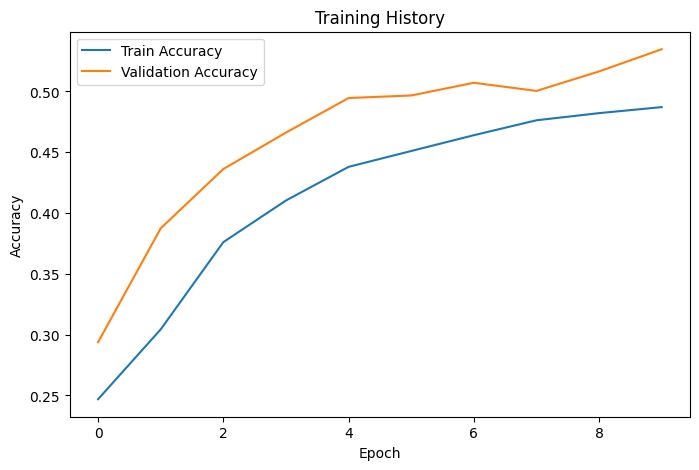

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training History')
plt.legend()

plt.show()

In [ ]:
!wget -O test_face.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

--2026-06-12 02:31:24--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91814 (90K) [image/jpeg]
Saving to: ‘test_face.jpg’

test_face.jpg       100%[===================>]  89.66K  --.-KB/s    in 0.001s  

2026-06-12 02:31:25 (80.4 MB/s) - ‘test_face.jpg’ saved [91814/91814]



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

emotion_labels = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

img = cv2.imread("test_face.jpg", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (48,48))
img = img.astype("float32") / 255.0

input_img = np.expand_dims(img, axis=-1)
input_img = np.expand_dims(input_img, axis=0)

prediction = model.predict(input_img)

class_id = np.argmax(prediction)

print("Predicted Emotion:", emotion_labels[class_id])
print("Confidence:", np.max(prediction)*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
Predicted Emotion: Angry
Confidence: 30.635994 %


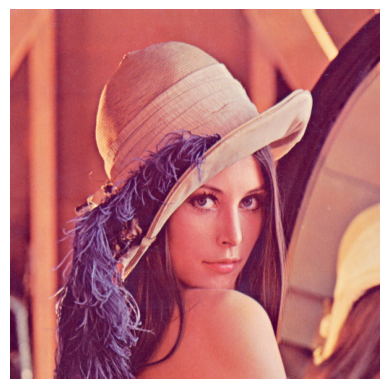

In [ ]:
img_show = cv2.imread("test_face.jpg")
img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

plt.imshow(img_show)
plt.axis("off")
plt.show()